In [11]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

In [12]:
df = pd.read_csv("life_data.csv")

df.head()

,Age,Gender,Sleep_Hours,Screen_Time,Exercise_Minutes,Water_Intake,Work_Study_Hours,Stress_Level,Mood,Productivity_Score,Burnout_Risk
0,56,Male,5.4,1.4,8,4.7,2.7,10,Neutral,41.7,High
1,46,Female,5.6,2.9,28,1.2,8.1,2,Sad,70.0,Medium
2,32,Male,6.8,8.2,37,5.0,5.2,6,Neutral,70.4,Medium
3,25,Male,5.4,6.5,64,1.8,5.4,9,Sad,37.6,High
4,38,Female,4.5,9.8,55,2.6,6.8,3,Happy,51.0,Medium


In [14]:
df.columns

Index(['Age', 'Gender', 'Sleep_Hours', 'Screen_Time', 'Exercise_Minutes',
       'Water_Intake', 'Work_Study_Hours', 'Stress_Level', 'Mood',
       'Productivity_Score', 'Burnout_Risk', 'Health_Score'],
      dtype='object')

In [15]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)


# Create new features

df["Health_Score"] = (
    df["Sleep_Hours"] +
    df["Exercise_Minutes"]/30 +
    df["Water_Intake"]
)


df["Screen_Impact"] = (
    df["Screen_Time"] / df["Work_Study_Hours"]
)

df.head()

,Age,Gender,Sleep_Hours,Screen_Time,Exercise_Minutes,Water_Intake,Work_Study_Hours,Stress_Level,Mood,Productivity_Score,Burnout_Risk,Health_Score,Screen_Impact
0,56,Male,5.4,1.4,8,4.7,2.7,10,Neutral,41.7,High,10.366667,0.518519
1,46,Female,5.6,2.9,28,1.2,8.1,2,Sad,70.0,Medium,7.733333,0.358025
2,32,Male,6.8,8.2,37,5.0,5.2,6,Neutral,70.4,Medium,13.033333,1.576923
3,25,Male,5.4,6.5,64,1.8,5.4,9,Sad,37.6,High,9.333333,1.203704
4,38,Female,4.5,9.8,55,2.6,6.8,3,Happy,51.0,Medium,8.933333,1.441176


In [16]:
# Mean
df.mean(numeric_only=True)


# Median
df.median(numeric_only=True)


# Mode
df.mode().iloc[0]


# Description
df.describe()

,Age,Sleep_Hours,Screen_Time,Exercise_Minutes,Water_Intake,Work_Study_Hours,Stress_Level,Productivity_Score,Health_Score,Screen_Impact
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.546400,6.492090,6.537460,59.97140,2.997100,7.004670,5.565300,69.632100,11.488237,1.168890
std,12.014287,1.438401,3.175004,35.31452,1.162445,2.873973,2.899824,20.759118,2.188246,0.914097
min,18.000000,4.000000,1.000000,0.00000,1.000000,2.000000,1.000000,2.500000,5.333333,0.083333
25%,28.000000,5.200000,3.800000,29.00000,2.000000,4.500000,3.000000,54.675000,9.900000,0.540172
50%,39.000000,6.500000,6.600000,60.00000,3.000000,7.000000,6.000000,70.400000,11.466667,0.931034
75%,49.000000,7.700000,9.300000,91.00000,4.000000,9.500000,8.000000,86.700000,13.033333,1.481481
max,59.000000,9.000000,12.000000,120.00000,5.000000,12.000000,10.000000,100.000000,17.500000,5.900000


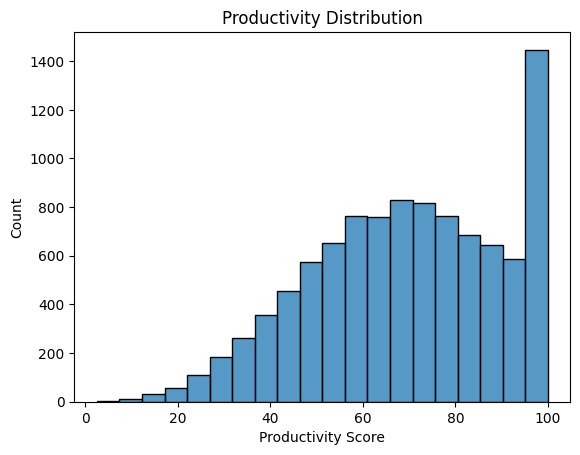

In [18]:
sns.histplot(
    df["Productivity_Score"],
    bins=20
)

plt.title("Productivity Distribution")
plt.xlabel("Productivity Score")
plt.ylabel("Count")
plt.show()

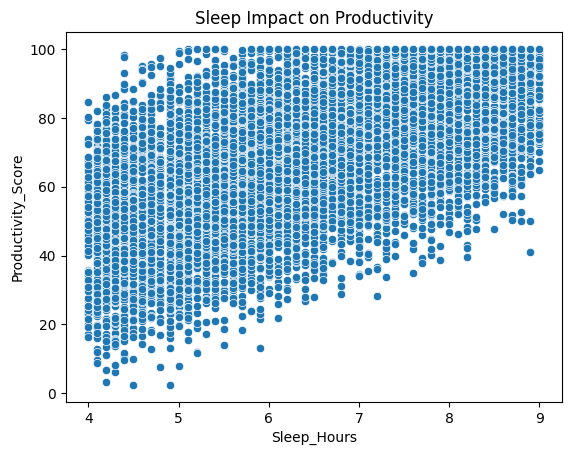

In [19]:
sns.scatterplot(
    data=df,
    x="Sleep_Hours",
    y="Productivity_Score"
)

plt.title("Sleep Impact on Productivity")
plt.show()

In [34]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Encode categorical columns
categorical_cols = [
    "Gender",
    "Mood",
    "Burnout_Risk"
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])


# Create X after encoding
X = df.drop("Productivity_Score", axis=1)

# Check
print(X.dtypes)

Age                   int64
Gender                int64
Sleep_Hours         float64
Screen_Time         float64
Exercise_Minutes      int64
Water_Intake        float64
Work_Study_Hours    float64
Stress_Level          int64
Mood                  int64
Burnout_Risk          int64
Health_Score        float64
Screen_Impact       float64
Burnout_Level         int64
dtype: object


In [35]:
X = df.drop("Productivity_Score", axis=1)

In [37]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])
df["Mood"] = encoder.fit_transform(df["Mood"])
df["Burnout_Risk"] = encoder.fit_transform(df["Burnout_Risk"])

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
X = df.drop("Productivity_Score", axis=1)

y = df["Productivity_Score"]


X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
reg_models = {

"Linear Regression":
LinearRegression(),

"Ridge Regression":
Ridge(),

"Lasso Regression":
Lasso(),

"Random Forest Regression":
RandomForestRegressor()

}

In [41]:
reg_results={}

for name,model in reg_models.items():

    model.fit(X_train,y_train)

    prediction=model.predict(X_test)

    reg_results[name]={
        
        "MAE":
        mean_absolute_error(y_test,prediction),

        "RMSE":
        np.sqrt(mean_squared_error(y_test,prediction)),

        "R2 Score":
        r2_score(y_test,prediction)
    }


pd.DataFrame(reg_results).T

,MAE,RMSE,R2 Score
Linear Regression,1.883647,3.288183,0.975384
Ridge Regression,1.884755,3.288131,0.975385
Lasso Regression,3.121788,4.008037,0.963427
Random Forest Regression,2.029255,2.603259,0.984571


In [60]:
# Regression Model Comparison

reg_comparison = pd.DataFrame(reg_results).T

reg_comparison.sort_values(
    "R2 Score",
    ascending=False
)



# Find Best Regression Model

best_reg_model_name = reg_comparison["R2 Score"].idxmax()

best_reg_model = reg_models[best_reg_model_name]

best_reg_model.fit(
    X_train,
    y_train
)

# Save Regression Model

joblib.dump(
    best_reg_model,
    "lifelens_regression_model.pkl"
)

['lifelens_regression_model.pkl']

In [45]:
# ==============================
# CLASSIFICATION - Burnout Risk
# ==============================

X = df.drop(
    ["Productivity_Score","Burnout_Risk"],
    axis=1
)

y = df["Burnout_Risk"]


# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [46]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [43]:
clf_models={

"Logistic Regression":
LogisticRegression(),

"Random Forest Classifier":
RandomForestClassifier(),

"Gradient Boosting":
GradientBoostingClassifier(),

"SVM":
SVC()

}

In [47]:
classification_results={}


for name,model in clf_models.items():

    model.fit(X_train,y_train)

    prediction=model.predict(X_test)


    classification_results[name]={

    "Accuracy":
    accuracy_score(y_test,prediction),

    "Precision":
    precision_score(
    y_test,prediction,
    average="weighted"
    ),

    "Recall":
    recall_score(
    y_test,prediction,
    average="weighted"
    ),

    "F1 Score":
    f1_score(
    y_test,prediction,
    average="weighted"
    )

}


pd.DataFrame(classification_results).T

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,1.0,1.0,1.0,1.0
Random Forest Classifier,1.0,1.0,1.0,1.0
Gradient Boosting,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0


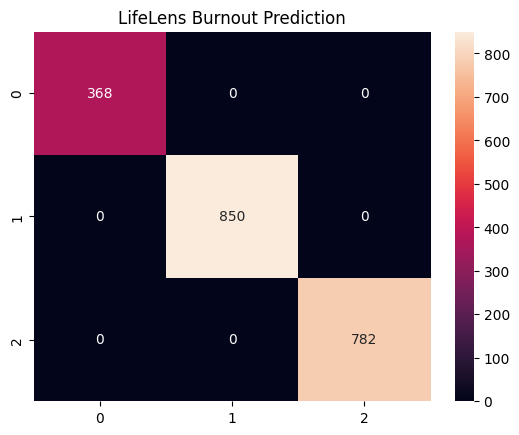

In [48]:
cm = confusion_matrix(
    y_test,
    prediction
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
"LifeLens Burnout Prediction"
)

plt.show()

In [49]:
comparison = pd.DataFrame(
classification_results
).T


comparison.sort_values(
"Accuracy",
ascending=False
)

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,1.0,1.0,1.0,1.0
Random Forest Classifier,1.0,1.0,1.0,1.0
Gradient Boosting,1.0,1.0,1.0,1.0
SVM,1.0,1.0,1.0,1.0


In [56]:
best_model_name = comparison[
"Accuracy"
].idxmax()


best_model = clf_models[
best_model_name
]

best_model.fit(
    X_train,
    y_train
)

joblib.dump(
    best_model,
    "lifelens_best_model.pkl"
)

print(
"Best Model:",
best_model_name
)

Best Model: Logistic Regression


In [58]:
joblib.dump(
    best_model,
    "lifelens_best_model.pkl"
)

['lifelens_best_model.pkl']

In [52]:
joblib.dump(
    scaler,
    "lifelens_scaler.pkl"
)

['lifelens_scaler.pkl']

In [54]:
joblib.dump(
    encoder,
    "lifelens_encoder.pkl"
)

['lifelens_encoder.pkl']

In [ ]:
#After comparing multiple regression and classification algorithms, Random Forest provided the best performance due to its ability to capture complex lifestyle patterns and feature interactions.